# 📘Week 3 Assignment — Country Intelligence System using Classification, Ensemble Learning & Clustering

**Topics Covered**
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Data Visualization
- Feature Scaling
- Correlation Analysis
- K-Means Clustering
- DBSCAN Clustering
- PCA (Principal Component Analysis)
- Cluster Evaluation using Silhouette Score
- Country Segmentation



**Objective**

The objective of this assignment is to analyze socio-economic and health indicators of countries using unsupervised machine learning techniques. The goal is to group countries with similar characteristics into meaningful clusters based on factors such as income, health expenditure, child mortality, life expectancy, and GDP.

The resulting clusters help reveal patterns in country development levels and provide insights that can support data-driven decision making for policy planning and resource allocation.

**Assignment Pipeline**

1. Load and Understand the Dataset
2. Analyze Feature Relationships using Correlation Heatmap
3. Standardize Features using StandardScaler
4. Apply and Evaluate K-Means Clustering
5. Apply and Compare DBSCAN Clustering
6. Visualize Clusters using PCA
7. Perform Cluster Profiling and Draw Conclusions
8. Results and Conclusions

In [62]:
import seaborn as sns

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    silhouette_score
)

**Step 1: Load and Understand the Dataset**

In [43]:
df = pd.read_csv("/Users/chhavibhatnagar/Desktop/archive/Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [44]:
print("Shape:", df.shape)

Shape: (167, 10)


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [46]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [47]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


**Step 2: Analyze Feature Relationships using Correlation Heatmap**

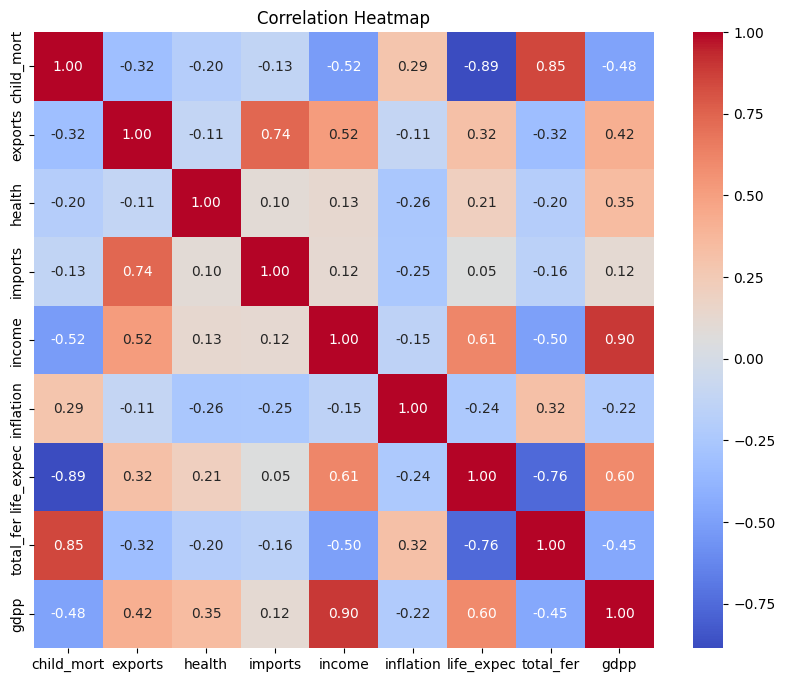

In [48]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

**Step 3: Standardize Features using StandardScaler**

In [49]:
features = df.drop('country', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(X_scaled.shape)

(167, 9)


**Step 4: Apply and Evaluate K-Means Clustering**

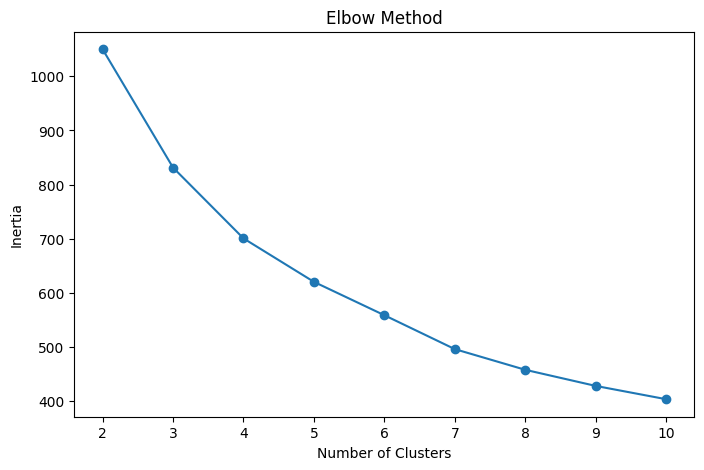

In [50]:
inertia = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [51]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K = {k} | Silhouette Score = {score:.4f}")

K = 2 | Silhouette Score = 0.2874
K = 3 | Silhouette Score = 0.2833
K = 4 | Silhouette Score = 0.2960
K = 5 | Silhouette Score = 0.2993
K = 6 | Silhouette Score = 0.2287
K = 7 | Silhouette Score = 0.2477
K = 8 | Silhouette Score = 0.2388
K = 9 | Silhouette Score = 0.2073
K = 10 | Silhouette Score = 0.2022


In [52]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

In [53]:
from sklearn.metrics import silhouette_score

k_score = silhouette_score(
    X_scaled,
    df['kmeans_cluster']
)

print("K-Means Score:", k_score)

K-Means Score: 0.2992594995920442


**Step 5:Apply and Compare DBSCAN Clustering**


In [54]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts())

dbscan_cluster
 0    137
-1     30
Name: count, dtype: int64


In [55]:
labels = df['dbscan_cluster']

valid = labels != -1

if len(set(labels[valid])) > 1:

    db_score = silhouette_score(
        X_scaled[valid],
        labels[valid]
    )

    print("DBSCAN Silhouette Score:", db_score)

else:
    print("Not enough clusters")

Not enough clusters


**Step 6: Visualize Clusters using PCA**

In [56]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PCA1', 'PCA2']
)

pca_df['Cluster'] = df['kmeans_cluster']

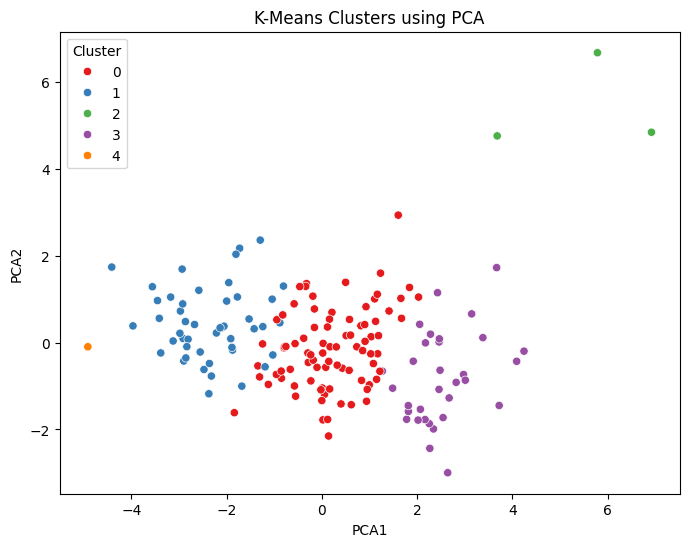

In [57]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1'
)

plt.title("K-Means Clusters using PCA")
plt.show()

**Step 7: Perform Cluster Profiling and Draw Conclusions**

In [58]:
cluster_profile = df.groupby(
    'kmeans_cluster'
).mean(numeric_only=True)

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,dbscan_cluster
kmeans_cluster,,,,,,,,,,
0,21.614286,40.976060,6.169048,47.518642,12801.071429,7.618857,73.004762,2.277619,6581.809524,-0.059524
1,90.793617,29.661915,6.462553,43.680851,3870.702128,9.951809,59.212766,4.974043,1900.255319,-0.319149
2,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667,-1.000000
3,5.181250,46.118750,9.088437,40.584375,44021.875000,2.513844,80.081250,1.788437,42118.750000,-0.187500
4,130.000000,25.300000,5.070000,17.400000,5150.000000,104.000000,60.500000,5.840000,2330.000000,-1.000000


**Countries in Each Cluster**

The following output lists the countries belonging to each cluster identified by the K-Means algorithm.

In [59]:
for i in sorted(df['kmeans_cluster'].unique()):

    print(f"\nCluster {i}")

    print(
        df[df['kmeans_cluster']==i]['country']
        .tolist()
    )


Cluster 0
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Cambodia', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Fiji', 'Georgia', 'Grenada', 'Guatemala', 'Guyana', 'Hungary', 'India', 'Indonesia', 'Iran', 'Jamaica', 'Jordan', 'Kazakhstan', 'Kyrgyz Republic', 'Latvia', 'Lebanon', 'Libya', 'Lithuania', 'Macedonia, FYR', 'Malaysia', 'Maldives', 'Mauritius', 'Micronesia, Fed. Sts.', 'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'Myanmar', 'Nepal', 'Oman', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Romania', 'Russia', 'Samoa', 'Saudi Arabia', 'Serbia', 'Seychelles', 'Slovak Republic', 'Sri Lanka', 'St. Vincent and the Grenadines', 'Suriname', 'Tajikistan', 'Thailand', 'Tonga', 'Tunisia', 'Turkey', 'Turkmenistan', 'Ukrain

**Cluster Analysis**

- Cluster 0 consists of countries with moderate socio-economic indicators, representing developing economies.
- Cluster 1 contains countries with relatively lower income, GDP, and life expectancy, along with higher child mortality rates.
- Cluster 2 represents a small group of high-income countries with strong economic performance and favorable development indicators.
- Cluster 3 includes developed countries characterized by high income, GDP, and overall socio-economic well-being.
- Cluster 4 forms a distinct outlier cluster with unusual economic characteristics, particularly very high inflation.

These results indicate that K-Means successfully grouped countries with similar socio-economic characteristics into meaningful clusters.

**Step 8:Results and Conclusions**

**Key Findings**

- K-Means produced meaningful country segments based on socio-economic indicators.
- The optimal number of clusters was selected using the Elbow Method and Silhouette Score.
- PCA visualization showed reasonable separation among clusters.
- DBSCAN identified limited cluster structures and several noise points.
- Cluster profiling revealed distinct groups representing different development levels.

**Conclusion**

The assignment successfully applied unsupervised learning techniques to segment countries based on socio-economic and health indicators. Among the evaluated approaches, K-Means provided the most interpretable clustering results and meaningful country-level insights.